# 1. Introduction
* Business overview
  
     Seasonally trending retail sales refer to buying patterns that follow certain cycles throughout the year, such as increased sales during holidays, 
    festive seasons or weather changes. For example, winter clothing products may sell better during the rainy season or winter, while beachwear tends to
    sell more in the summer.
    To capitalize on these seasonal trends, marketing strategies are adjusted to appeal to consumers at specific times. Marketing done before and during
    seasonal peaks usually involves promotions, discounts and thematic campaigns as appropriate. By studying seasonal trends, retailers can strategize 
    stock, set optimal prices, and design timely advertising campaigns to increase sales and reduce the risk of overstocking or under-stocking
   
      
 * Purpose
   
analysis purposes. It reflects typical retail sales patterns and is designed to support a variety of data science and business analytics projects.

# 2. Data overview

In [1]:
import numpy as np
import pandas as pd

In [7]:
# df = '/kaggle/input/retail-sales-data-with-seasonal-trends-and-marketing/Retail and wherehouse Sale.csv'
# df = pd.read_csv(df)

In [ ]:
# df = pd.read_csv(r"C:\Users\Dimple\Documents\IIM Skills - Capstone Projects\PYTHON\Retail and wherehouse Sale.csv")
df = pd.read_csv("Retail and wherehouse Sale.csv")

df.head(10)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0
5,2020,1,KYSELA PERE ET FILS LTD,100641,CORTENOVA VENETO P/GRIG - 750ML,WINE,2.76,0.0,6.0
6,2020,1,SANTA MARGHERITA USA INC,100749,SANTA MARGHERITA P/GRIG ALTO - 375ML,WINE,0.08,1.0,1.0
7,2020,1,BROWN-FORMAN BEVERAGES WORLDWIDE,1008,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...,BEER,0.00,0.0,2.0
8,2020,1,JIM BEAM BRANDS CO,10103,KNOB CREEK BOURBON 9YR - 100P - 375ML,LIQUOR,6.41,4.0,0.0
9,2020,1,INTERNATIONAL CELLARS LLC,101117,KSARA CAB - 750ML,WINE,0.33,1.0,2.0


In [9]:
df.shape                  # Rows & Columns

(30000, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          29967 non-null  object 
 3   ITEM CODE         30000 non-null  object 
 4   ITEM DESCRIPTION  30000 non-null  object 
 5   ITEM TYPE         30000 non-null  object 
 6   RETAIL SALES      29999 non-null  float64
 7   RETAIL TRANSFERS  30000 non-null  float64
 8   WAREHOUSE SALES   30000 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.1+ MB


In [11]:
## Retail Sales, Retail Transfers & Warehouse Sales are widely distributed as per the standard deviation

## To check if any null values ===

In [12]:
df.isna().sum()                                    #  OR   df.isnull().sum()

YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [13]:
df.nunique()

YEAR                    1
MONTH                   4
SUPPLIER              290
ITEM CODE           15668
ITEM DESCRIPTION    15732
ITEM TYPE               8
RETAIL SALES         3657
RETAIL TRANSFERS      542
WAREHOUSE SALES      1032
dtype: int64

In [14]:
## Data set has 1 year of data & major data comes from only 4 months, we have 15K+ items 

In [15]:
df['MONTH'].unique()

array([1, 7, 3, 9])

In [16]:
## so those four months are 1,7,3,9 

In [17]:
df['MONTH'].value_counts().sort_index()

## without using -> .sort_index() → sorted by frequency (highest first).
## using -> .sort_index() → sorted by the month number (natural chronological order).

MONTH
1    11987
3     5730
7    11190
9     1093
Name: count, dtype: int64

In [18]:
df['ITEM TYPE'].unique()        # so we have these total 8 categories of Item Type

array(['WINE', 'BEER', 'LIQUOR', 'STR_SUPPLIES', 'KEGS', 'REF', 'DUNNAGE',
       'NON-ALCOHOL'], dtype=object)

# 3. Data cleaning

In [19]:
## Finding duplicate data based on all columns

In [20]:
df.duplicated().sum()                  # OR   df.duplicated().values.any()   OR  df[df.duplicated(keep=False)]

# we have no duplicates in this data

np.int64(0)

In [21]:
## Handling missing value

In [22]:
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0)


# Remove rows that contain missing values in the 'RETAIL SALES' column
# df_cleaned = df.dropna(subset=['RETAIL SALES'])
# print(df_cleaned)

## This code deletes all rows where the RETAIL SALES column has missing (NaN) values and keeps only the clean records or simply fill with zero value to keep the rows.

In [23]:
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')

In [24]:
df.isna().sum()

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64

# 4. Exploratory Data Analysis

In [25]:
df.describe(include = 'number').T

,count,mean,std,min,25%,50%,75%,max
YEAR,30000.0,2020.000000,0.000000,2020.00,2020.0,2020.00,2020.00,2020.0
MONTH,30000.0,3.911467,2.836788,1.00,1.0,3.00,7.00,9.0
RETAIL SALES,30000.0,6.939565,33.080527,-0.42,0.0,0.16,2.92,2739.0
RETAIL TRANSFERS,30000.0,6.594058,27.879428,-6.00,0.0,0.00,3.00,1507.0
WAREHOUSE SALES,30000.0,27.431031,272.166085,-3999.00,0.0,1.00,6.00,18317.0


#### The data above summarizes retail sales and transfer statistics for a one-year period (2020). Here’s a brief explanation of each column:

1. YEAR: All entries are from 2020, with no variation (mean, min, and max are all 2020).
2. MONTH: Data spans months 1 to 9, with an average in month 3, indicating that data may be more concentrated at the beginning of the year. 
          Percentiles show that many transactions occurred from early to mid-year.
3. RETAIL SALES: Retail sales have an average value of 17.5 with a wide distribution (standard deviation of 51.6). The minimum value is slightly 
                 below zero (-0.42), which could indicate returns or significant discounts, while the maximum reaches 2739. This distribution suggests a
                 few large sales worth noting.

4. RETAIL TRANSFERS: Retail transfers average slightly lower at 16.5 with a standard deviation of 43.0, also showing some negative values, which could
                     indicate adjustments. The maximum value is high (1507), suggesting some substantial transfers.

5. WAREHOUSE SALES: Warehouse sales vary greatly, with an average of 52.5 but a standard deviation of 420.9—indicating a few very large transactions. 
                    The minimum of -3999 likely indicates a large return or correction, while the maximum of 18317 suggests exceptionally large sales.

#### Insights
Wide Distribution in Retail and Transfer: The large difference between minimum and maximum values in RETAIL SALES and RETAIL TRANSFERS could suggest 
specific sales patterns, such as deep discounts or special events that drive large sales.
Fluctuating Warehouse Sales: The wide range in WAREHOUSE SALES indicates significant fluctuations, which may relate to stock replenishments or clearance
of old stock.
Negative Values: Negative values in RETAIL SALES, RETAIL TRANSFERS, and WAREHOUSE SALES need further investigation, as they may reflect large returns 
or order cancellations.
These insights can help plan sales strategies and stock management, particularly by understanding factors driving large sales or special events that 
might impact regular sales patterns Normal Sales.

In [26]:
df.describe(include = 'O').T

,count,unique,top,freq
SUPPLIER,30000,291,"THE COUNTRY VINTNER, LLC DBA WINEBOW",2041
ITEM CODE,30000,15668,14206,4
ITEM DESCRIPTION,30000,15732,TENTH WARD DIST CO CARAWAY RYE - 750ML,5
ITEM TYPE,30000,8,WINE,18680


#### This data provides a brief overview of attributes related to suppliers, item codes, item descriptions, and product types within the dataset. Here’s a summary:

1. **SUPPLIER**: There are 291 unique suppliers among 11,508 entries, with the top supplier being *E & J GALLO WINERY*, appearing 676 times. 
                 This suggests that this supplier contributes significantly to the sales data.
2. **ITEM CODE**: There are 6,207 unique item codes, with the most frequent item (code *11711*) appearing 4 times. The high variation in codes 
                  indicates a diverse product offering.
3. **ITEM DESCRIPTION**: Out of 11,508 entries, there are 6,245 unique product descriptions, with the most common description being 
                        *BLACK STALLION SAUVIGNON BLANC - 750ML*, which appears 4 times. This suggests that each product typically has a unique 
                        description, reflecting a wide range of items.
4. **ITEM TYPE**: The product type is dominated by *WINE*, which appears 5,674 times out of 11,508 entries, indicating that the main product in this
                  dataset is wine.

#### Insights
- **Wine Product Dominance**: The *WINE* category dominates the dataset, indicating that the primary focus of the inventory is on wine. This could 
                              inform marketing strategies, especially for wine products.
- **Key Supplier**: *E & J GALLO WINERY* is the most frequent supplier, suggesting they are a major partner in the supply chain. Further exploration
                    of collaborations or price negotiations with this supplier could improve efficiency.
- **Product Diversity**: With numerous unique item codes and descriptions, there is a wide range of products in the inventory. This variety can be
                         leveraged to appeal to a broader market segment or to create targeted promotional campaigns for less common products.

These insights could help optimize marketing strategies, inventory management, and supplier relationships.d customer choice.

In [27]:
df['MONTH'].unique()

array([1, 7, 3, 9])

There is data for 4 months and if 1 - January then 7 - July, 3 - March, 9 - September. Later, when doing seasonal trend analysis and/or 
predictive modelling I will need to reckon with it. 
Let's also check the distribution of values here.

In [28]:
df['MONTH'].value_counts()

MONTH
1    11987
7    11190
3     5730
9     1093
Name: count, dtype: int64

We have twice more entries for January and July than for March. And for September it is even less. Assuming the data is good and complete then 
we might think more goods were sold in January and July than in September and March. But then again it's going to be hard to do any kind of relevant 
trends analysis.

### 4.1 Supplier Performance

In [29]:
df.groupby('SUPPLIER')[["RETAIL SALES","RETAIL TRANSFERS","WAREHOUSE SALES"]].sum()

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
SUPPLIER,,,
A I G WINE & SPIRITS,0.00,0.0,26.00
ADAMBA IMPORTS INTL,6.07,6.0,1.00
AIKO IMPORTERS INC,0.08,0.0,1.00
ALLAGASH BREWING COMPANY,61.65,62.0,847.00
ALLIED IMPORTERS USA LTD,0.00,1.0,1.00
...,...,...,...
WINERY EXCHANGE INC,0.08,0.0,22.00
YOUNG WON TRADING INC,507.32,509.0,842.95
YUENGLING BREWERY,2734.59,2670.0,14206.84


### 4.2 Item Type Contribution

In [30]:
df.groupby('ITEM TYPE')[["RETAIL SALES","WAREHOUSE SALES"]].sum()

,RETAIL SALES,WAREHOUSE SALES
ITEM TYPE,,
BEER,59538.76,697279.68
DUNNAGE,0.00,-12115.00
KEGS,0.00,8400.00
LIQUOR,81742.85,8796.90
NON-ALCOHOL,6824.62,2438.42
REF,46.27,-1329.00
STR_SUPPLIES,345.60,0.00
WINE,59688.84,119459.93


## 4.3 Monthly Trends

In [31]:
df.groupby('MONTH')[["RETAIL SALES","WAREHOUSE SALES"]].sum()

,RETAIL SALES,WAREHOUSE SALES
MONTH,,
1,74318.77,284114.72
3,34523.90,113305.22
7,94538.96,418094.42
9,4805.31,7416.57


## 4.4 Top 10 Products

In [32]:
df.groupby('ITEM DESCRIPTION')["RETAIL SALES"].sum().sort_values(ascending = False).head(10)

ITEM DESCRIPTION
ICE                                          3842.00
CORONA EXTRA LOOSE NR - 12OZ                 2845.00
TITO'S HANDMADE VODKA - 1.75L                2330.99
HEINEKEN LOOSE NR - 12OZ                     2096.00
STELLA ARTOIS LOOSE NR - 11.2OZ              1348.00
MILLER LITE  HIGH GRAPHIC LOOSE NR - 12OZ    1258.00
CORONA EXTRA 2/12 NR - 12OZ                  1105.00
MILLER LITE 30PK CAN - 12OZ                  1045.00
YUENGLING LAGER LOOSE NR - 12OZ               961.00
BUD LIGHT 30PK CAN                            958.00
Name: RETAIL SALES, dtype: float64

## 4.5 Top 10 Suppliers

In [33]:
df.groupby('SUPPLIER')["RETAIL SALES"].sum().sort_values(ascending = False).head(10)

SUPPLIER
DIAGEO NORTH AMERICA INC        13840.54
E & J GALLO WINERY              12742.24
ANHEUSER BUSCH INC              10091.64
CONSTELLATION BRANDS             9931.78
JIM BEAM BRANDS CO               9845.79
CROWN IMPORTS                    9341.80
SAZERAC CO                       7739.14
MILLER BREWING COMPANY           7737.55
BACARDI USA INC                  6121.70
HEAVEN HILL DISTILLERIES INC     6075.45
Name: RETAIL SALES, dtype: float64

## 5. DATA Visualisation

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt 

#### Supplier & Product Insights -->>

#### 5.1 Top 10 Suppliers by Retail Sales

In [35]:
top_suppliers = df.groupby('SUPPLIER')["RETAIL SALES"].sum().nlargest(10).reset_index()
top_suppliers

# OR 
# df.groupby('SUPPLIER')["RETAIL SALES"].sum().sort_values(ascending = False).head(10)

# Both gives similar results but -
# nlargest(10) → directly picks top 10 highest values, Faster & more efficient (no full sorting), Cleaner syntax, Best when you only want top N values.
# sort_values() → sorts ALL suppliers, Full sorted list, Ranking beyond top 10, More flexible for deeper analysis

,SUPPLIER,RETAIL SALES
0,DIAGEO NORTH AMERICA INC,13840.54
1,E & J GALLO WINERY,12742.24
2,ANHEUSER BUSCH INC,10091.64
3,CONSTELLATION BRANDS,9931.78
4,JIM BEAM BRANDS CO,9845.79
5,CROWN IMPORTS,9341.80
6,SAZERAC CO,7739.14
7,MILLER BREWING COMPANY,7737.55
8,BACARDI USA INC,6121.70
9,HEAVEN HILL DISTILLERIES INC,6075.45


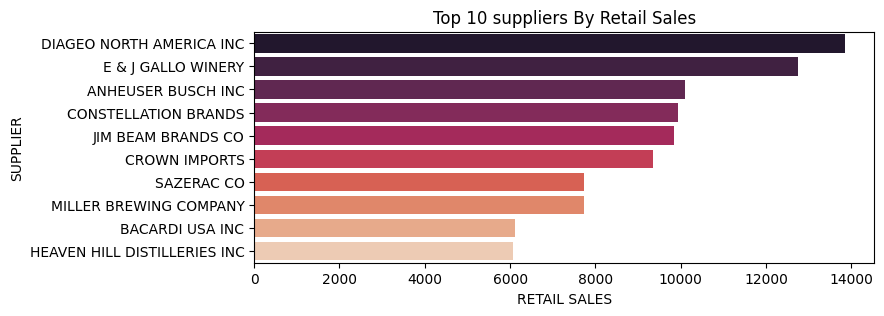

In [36]:
plt.figure(figsize=(8,3))
sns.barplot(data = top_suppliers,x = 'RETAIL SALES', y = 'SUPPLIER', hue = 'SUPPLIER',  palette="rocket" , legend = False)
plt.title('Top 10 suppliers By Retail Sales')
plt.show()

#### 5.2 Item Type By Retail Sales

In [37]:
item_retails = df.groupby('ITEM TYPE')["RETAIL SALES"].sum()
item_retails

ITEM TYPE
BEER            59538.76
DUNNAGE             0.00
KEGS                0.00
LIQUOR          81742.85
NON-ALCOHOL      6824.62
REF                46.27
STR_SUPPLIES      345.60
WINE            59688.84
Name: RETAIL SALES, dtype: float64

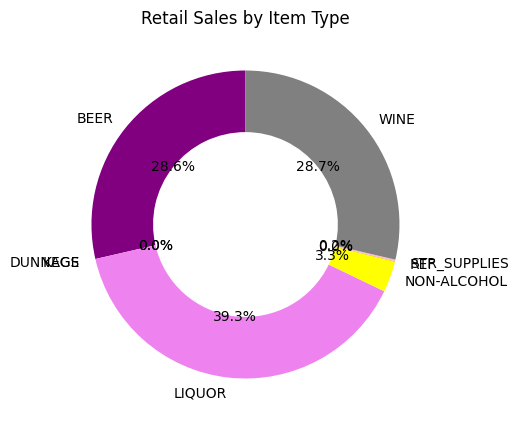

In [38]:
plt.figure(figsize=(5, 5))
c = ["purple","pink", "grey","violet", "yellow"]
plt.pie(
    item_retails.values,
    labels=item_retails.index,
    colors = c,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}   
)

plt.title('Retail Sales by Item Type')
plt.show()


In [39]:
#### 5.3 Item Type By Retail Sales

In [40]:
# Grouping numeric and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'object']).columns

print("numeric col:", numerical_columns.tolist())
print("categorical col:", categorical_columns.tolist())

numeric col: ['YEAR', 'MONTH', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
categorical col: ['SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE']


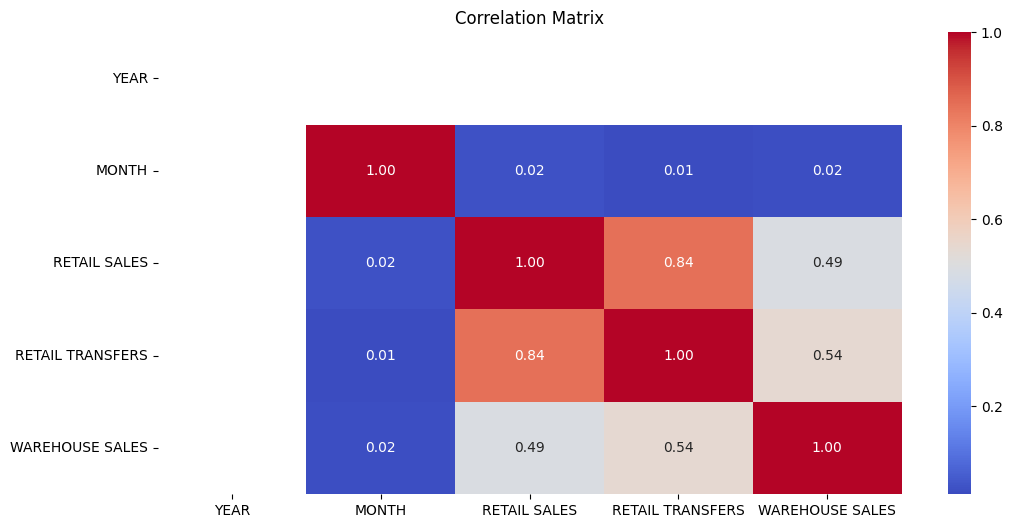

In [41]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


### Correlation Matrix Summary

1. **High Correlation between RETAIL SALES and RETAIL TRANSFERS**:
   - The correlation between RETAIL SALES and RETAIL TRANSFERS is **0.84**, indicating a very strong positive relationship. This suggests that an 
     increase in retail sales is often accompanied by an increase in retail transfers, likely indicating that as sales rise, stock transfers also
     increase to meet demand.

2. **Relationship between RETAIL SALES and WAREHOUSE SALES**:
   - The correlation between RETAIL SALES and WAREHOUSE SALES is **0.49**, showing a moderate positive relationship. This implies that while there 
     is some relationship between retail sales and warehouse sales, it’s not as strong as the correlation between RETAIL SALES and RETAIL TRANSFERS.

3. **Correlation between RETAIL TRANSFERS and WAREHOUSE SALES**:
   - The correlation of **0.54** between RETAIL TRANSFERS and WAREHOUSE SALES also indicates a moderate positive relationship. This means that an 
     increase in retail transfers tends to coincide with an increase in warehouse sales.

4. **Correlation between MONTH or YEAR and Sales/Transfers Variables**:
   - The correlation between the variables MONTH and YEAR with the sales variables (RETAIL SALES, WAREHOUSE SALES) and transfers (RETAIL TRANSFERS) 
     is very low (close to 0). This suggests that month or year factors don’t have a significant linear impact on sales or transfers. This might
     indicate that other factors are more influential on sales and transfers than time.

### Interesting Insights

- **Stock Management**:
   - The high correlation between RETAIL SALES and RETAIL TRANSFERS provides insights into stock management. To meet the rising demand in sales, stock transfers must be managed carefully to avoid shortages. This can serve as a basis for logistics managers to monitor transfer levels in line with sales levels.

- **Relationship between Retail and Warehouse Sales**:
   - Although there is a moderate correlation between RETAIL SALES and WAREHOUSE SALES, it is not as strong as the relationship between RETAIL SALES and RETAIL TRANSFERS. This may suggest that, while the warehouse supports retail sales, other factors also influence retail sales beyond warehouse stock, such as promotional strategies or customer behavior.

- **Insignificant Role of Time**:
   - The low correlation between time variables (MONTH and YEAR) and sales/transfers indicates that there is no strong seasonal pattern or annual trend in the data. This could mean that the products sold are not affected by seasonality, or that customer consumption patterns are relatively stable throughout the year.

With these insights, you could focus further analysis on the relationship between sales and stock transfers, and investigate other factors beyond time that may have a more significant influence on sales and transfers, such as marketing campaigns or product promotions.

In [42]:
#### 5.4 Monthly Retail Sales

In [43]:
monthly_retail = df.groupby('MONTH')['RETAIL SALES'].sum().reset_index()
monthly_retail

,MONTH,RETAIL SALES
0,1,74318.77
1,3,34523.90
2,7,94538.96
3,9,4805.31


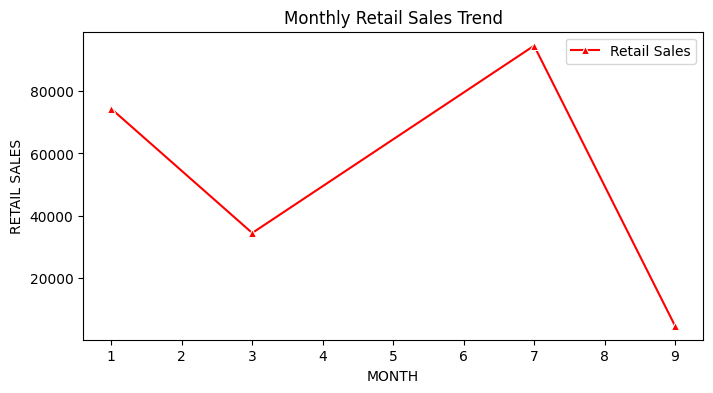

In [44]:
plt.figure(figsize=(8, 4))
sns.lineplot(data = monthly_retail, x = 'MONTH', y = 'RETAIL SALES', marker = '^', color ='red', label = 'Retail Sales') 
plt.title("Monthly Retail Sales Trend")

plt.legend()
plt.show()


In [45]:
#### 5.5 Monthly Retail Sales vs Warehouse Sales 

In [46]:
monthly_sales = df.groupby('MONTH')[['RETAIL SALES', 'WAREHOUSE SALES']].sum().reset_index()
monthly_sales

,MONTH,RETAIL SALES,WAREHOUSE SALES
0,1,74318.77,284114.72
1,3,34523.90,113305.22
2,7,94538.96,418094.42
3,9,4805.31,7416.57


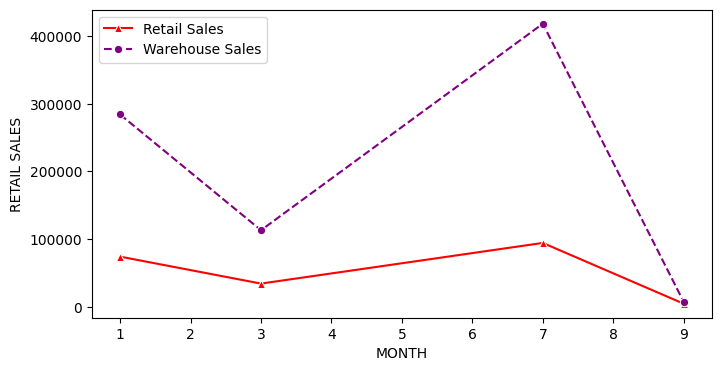

In [47]:
plt.figure(figsize=(8, 4))
sns.lineplot(data = monthly_sales, x = 'MONTH', y = 'RETAIL SALES', marker = '^', color ='red', label = 'Retail Sales') 
sns.lineplot(data = monthly_sales, x = 'MONTH', y = 'WAREHOUSE SALES', marker = 'o', ls = '--', color ='purple', label = 'Warehouse Sales') 
plt.legend()
plt.show()


In [48]:
#### 5.5 Monthly Trends -- Retail vs Warehouse vs Retail Transfers

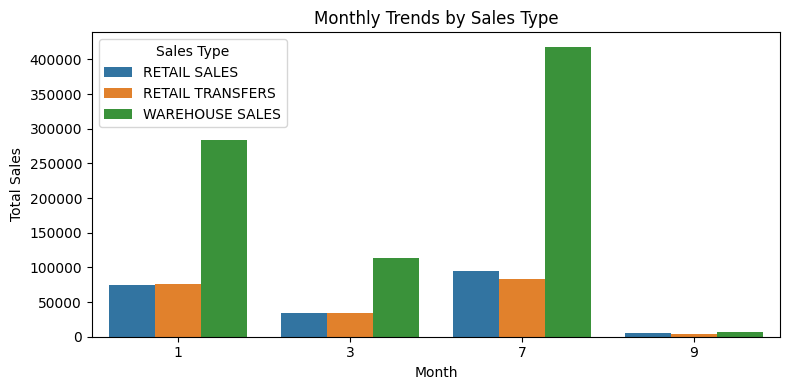

In [49]:
monthly_trends = df.groupby('MONTH')[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].sum().reset_index()
monthly_trends

plt.figure(figsize=(8, 4))
monthly_long = monthly_trends.melt(
    id_vars='MONTH',
    value_vars=['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
    var_name='Sales Type',
    value_name='Amount'
)
sns.barplot(
    data=monthly_long,
    x='MONTH',
    y='Amount',
    hue='Sales Type'
)

plt.title('Monthly Trends by Sales Type')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title='Sales Type')
plt.tight_layout()
plt.show()


In [50]:
#### 5.6 Top 10 Products by Retail Sales

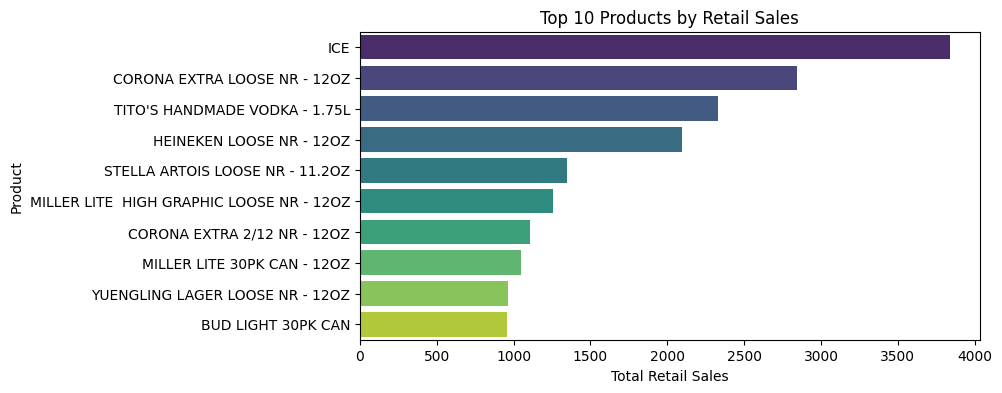

In [51]:
top_products = df.groupby('ITEM DESCRIPTION')["RETAIL SALES"].sum().nlargest(10).reset_index()
#top_products

plt.figure(figsize=(8, 4))
sns.barplot(data=top_products, x="RETAIL SALES", y="ITEM DESCRIPTION", hue = 'ITEM DESCRIPTION', palette="viridis")
plt.title("Top 10 Products by Retail Sales")
plt.xlabel("Total Retail Sales")
plt.ylabel("Product")
plt.show()


In [55]:
df_cleaned = df
df_cleaned

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0
...,...,...,...,...,...,...,...,...,...
29995,2020,3,"THE COUNTRY VINTNER, LLC DBA WINEBOW",352322,FORTALEZA ANEJO TEQUILA - 750ML,LIQUOR,0.33,0.0,0.0
29996,2020,3,OSLO ENTERPRISE,352324,DOMAINE BRICHOT BLANC - 750ML,WINE,0.00,0.0,0.0
29997,2020,3,OPICI FAMILY DISTRIBUTING OF MD,352354,LOTE 44 MALBEC - 750ML,WINE,0.00,0.0,6.0
29998,2020,3,CAMPARI AMERICA LLC,35238,SKYY VODKA - 1.75L,LIQUOR,329.04,302.0,0.0


In [56]:
df_cleaned.to_csv("Cleaned Retail and Warehouse Sales.csv", index = False)

## 6. Conclusion 

### 1. Year and Month Variables:
- All data is from the year 2020, and the distribution of months shows that most transactions occurred in the beginning to mid-year, with January and July having twice as many entries compared to March and September.

### 2. Retail Sales and Retail Transfers:
- Retail sales show a wide distribution with an average value of 17.5 and a large standard deviation (51.6), indicating significant large transactions.
- Retail transfers average slightly lower at 16.5 but also show substantial variability.
- Warehouse sales have very high variation, with an average of 52.5 and a standard deviation of 420.9, indicating unusually large transactions.

### 3. Negative Values in Sales and Transfers:
- Negative values in retail sales, transfers, and warehouse sales may indicate returns or order cancellations, which should be further investigated.

### 4. Suppliers and Item Codes:
- There are 291 unique suppliers, with E & J GALLO WINERY being the largest supplier.
- There are 6,207 unique item codes, and the majority of products sold are wine.

---

# Key Insights

### 1. Wide Distribution in Retail Sales and Transfers:
- The large fluctuations in retail sales and transfers might indicate specific events (such as major discounts or special events) that drive large transactions.

### 2. Fluctuating Warehouse Sales:
- The wide range in warehouse sales likely relates to stock replenishments or clearance of old stock.

### 3. Importance of Stock Management:
- The high correlation between retail sales and retail transfers suggests that proper management of stock transfers is critical to avoid shortages during times of high demand.

### 4. Dominance of Wine Products:
- Wine dominates the dataset, which could be leveraged for focused marketing strategies.

### 5. Time Variables Have Little Impact:
- The low correlation between time variables (month and year) and sales/transfer data suggests that seasonal patterns or yearly trends may not have a significant impact on the data.

---

# Solutions and Next Steps

### 1. Analyze Special Events:
- Further analyze large transactions (both maximum and negative values) to understand the factors influencing fluctuations in sales and transfers.

### 2. Improve Stock Management:
- To prevent stock shortages, logistics managers should focus on the close relationship between retail sales and retail transfers, paying attention to major sales events that may occur.

### 3. Optimize Wine Marketing Strategy:
- Since wine dominates the products, targeted marketing campaigns and promotions could further increase sales in this category.

### 4. Consider Other Factors Besides Time:
- Given the low correlation between time and sales, other factors (such as promotions or consumer behavior) may have a more significant impact, and these should be analyzed further for future planning.

### 5. Focus on Dominant Supplier Relationships:
- With a supplier like E & J GALLO WINERY being dominant, there is an opportunity to explore collaborative relationships or price negotiations to improve supply chain efficiency.